In [ ]:
def differentiate_single_state_reg_and_multiple_states(all_t1_t2_measurements, gene_pairs, twin_correlation_matrix, random_correlation_matrix, gene_list, z_score_threshold=10, verbose = True):
    """
    Separates potential regulatory gene pairs into multiple-state vs single-state regulation.

    Parameters
    ----------
    all_t1_t2_measurements : pd.DataFrame
        The cell-gene dataframe containing sample information.
    potential_regulation : list of tuple
        List of gene pairs (gene_i, gene_j) with potential regulation.
    twin_correlation_matrix : pd.DataFrame
        Twin pair correlation matrix at time t2.
    random_correlation_matrix : pd.DataFrame
        Random pair correlation matrix at time t2.
    gene_list : list of str
        List of gene names (e.g., 'gene_1') in correct matrix order.
    z_score_threshold : float, optional
        Threshold for abs(random / twin) above which a pair is considered multi-state.
    Returns
    -------
    multiple_states_gene_pairs : list of tuple
        Gene pairs with abs(random / twin) >= threshold_ratio.

    single_state_regulation : list of tuple
        Gene pairs with z-score between random pair correlations and twin pair correlation greater than 10.
    """
    multiple_states_gene_pairs = []
    single_state_regulation = []

    random_pair_correlation_distribution = generate_random_shuffle(all_t1_t2_measurements, gene_list=gene_list)
    for gene_i, gene_j in gene_pairs:
        try:
            t_corr = twin_correlation_matrix.loc[gene_i, gene_j]
            r_corr = get_correlations(random_pair_correlation_distribution, gene_i, gene_j)
            r_corr_std = np.std(r_corr)
            if r_corr_std == 0:
                # All random correlations are identical (very rare)
                print(f"Warning: Zero variance in random correlations for {gene_i}-{gene_j}")
                single_state_regulation.append((gene_i, gene_j))
                continue
            z_score = (t_corr - np.mean(r_corr))/r_corr_std
            if verbose:
                plt.hist(r_corr)
                plt.axvline(t_corr, linestyle = "--", c = "red", label = "Twin correlation at time t1")
                plt.xlabel("Correlations")
                plt.ylabel("Freuquency")
                plt.title(f"Random pair correlations vs twin correlation at time t1 \
                    \n between {gene_i} and {gene_j} \
                    \n Z-score = {z_score}")
                plt.show()
                
            if abs(z_score) > abs(z_score_threshold):
                multiple_states_gene_pairs.append((gene_i, gene_j))
            else:
                single_state_regulation.append((gene_i, gene_j))
        except ZeroDivisionError:
            # Handle case where twin correlation is 0
            raise ValueError(f"Division by zero for {gene_i} and {gene_j}")
        except KeyError:
            raise ValueError(f"Missing gene pair ({gene_i}, {gene_j}) in correlation matrices.")

    return multiple_states_gene_pairs, single_state_regulation

In [ ]:
def get_correlations(correlation_dict, gene_i, gene_j):
   return correlation_dict[tuple(sorted([gene_i, gene_j]))]

def generate_random_shuffle(simulation_data, gene_list, n_shuffles=10000, random_state=42):
   np.random.seed(random_state)
   
   rep_0 = simulation_data[simulation_data['replicate'] == 1].reset_index(drop=True)
   rep_1 = simulation_data[simulation_data['replicate'] == 2].reset_index(drop=True)
   gene_cols = [f"{gene}_mRNA" for gene in gene_list]
   min_cells = min(len(rep_0), len(rep_1))
   expr_0 = rep_0[gene_cols].iloc[:min_cells].values
   expr_1 = rep_1[gene_cols].iloc[:min_cells].values

   n_cells, n_genes = expr_0.shape
   triu_indices = np.triu_indices(n_genes, k=1)
   gene_pairs = [(gene_list[i], gene_list[j]) for i, j in zip(triu_indices[0], triu_indices[1])]
   
   all_shuffle_indices = np.array([np.random.permutation(n_cells) for _ in range(n_shuffles)])
   all_correlations = np.zeros((n_shuffles, len(gene_pairs)))
   
   for batch_start in range(0, n_shuffles, 100):
       batch_end = min(batch_start + 100, n_shuffles)
       for i, shuffle_idx in enumerate(all_shuffle_indices[batch_start:batch_end]):
           expr_1_shuffled = expr_1[shuffle_idx]
           deltas = expr_0 - expr_1_shuffled
           ranked_deltas = np.apply_along_axis(rankdata, 0, deltas)
           corr_matrix = np.corrcoef(ranked_deltas.T)
           all_correlations[batch_start + i] = corr_matrix[triu_indices]
   
   # Store with sorted keys to avoid duplicates
   correlation_dict = {}
   for i, (gene_i, gene_j) in enumerate(gene_pairs):
       key = tuple(sorted([gene_i, gene_j]))
       correlation_dict[key] = all_correlations[:, i]
   
   return correlation_dict

In [4]:
# ============================================================
# Spearman summary tables per file (exact print format)
# Rows = gene pairs; Cols = Spearman_t1, Spearman_t2, ΔSpearman, Spearman(Δ,Δ)
# Twin-paired snapshots + within-twin deltas
# ============================================================

import os
import numpy as np
import pandas as pd

# -----------------------------
# Basic utilities
# -----------------------------

def extract_title(filepath: str) -> str:
    """
    Create a short, readable title from a CSV path.
    If the filename contains ..._ncells_<N>_<motif>_<hash>.csv,
    return just the <motif> part; otherwise return the stem.
    """
    base = os.path.basename(filepath).replace('.csv', '')
    parts = base.split('_')
    if 'ncells' in parts:
        idx = parts.index('ncells')
        # everything after 'ncells <N>' up to (but excluding) the final token (often a hash)
        return '_'.join(parts[idx+2:-1]) or base
    return base

def _pearson_nan(a: np.ndarray, b: np.ndarray) -> float:
    """
    Pearson correlation that ignores NaNs.
    Returns NaN if fewer than 2 valid points or zero variance in either vector.
    """
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    ok = np.isfinite(a) & np.isfinite(b)
    a, b = a[ok], b[ok]
    if a.size < 2: return np.nan
    if a.var(ddof=1) == 0 or b.var(ddof=1) == 0: return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def _spearman_nan(a: np.ndarray, b: np.ndarray) -> float:
    """
    Spearman correlation implemented as Pearson on mid-ranks (handles ties).
    Ignores NaNs; returns NaN if insufficient/degenerate.
    """
    a = pd.Series(a, dtype=float); b = pd.Series(b, dtype=float)
    ok = a.notna() & b.notna()
    if ok.sum() < 2: return np.nan
    ra = a[ok].rank(method='average'); rb = b[ok].rank(method='average')
    return _pearson_nan(ra.values, rb.values)

# -----------------------------
# Twin pairing & Δ construction
# -----------------------------

def paired_twins_matrix(
    filepath: str, t1, t2,
    time_col='time_step',
    id_cols=('clone_id','replicate'),
    y_col='gene_1_mRNA',
    x1_col='gene_2_mRNA',
    x2_col='gene_3_mRNA'
) -> pd.DataFrame:
    """
    Return a wide table with the SAME twins at t1 & t2:
      columns: Y_t1, X1_t1, X2_t1, Y_t2, X1_t2, X2_t2
    """
    df = pd.read_csv(filepath)
    keys = list(id_cols)
    cols_keep = keys + [y_col, x1_col, x2_col]

    t1_df = df.loc[df[time_col] == t1, cols_keep].copy()
    t2_df = df.loc[df[time_col] == t2, cols_keep].copy()

    # Keep only twins present at BOTH times
    k = t1_df[keys].drop_duplicates().merge(
        t2_df[keys].drop_duplicates(), on=keys, how='inner'
    )

    t1_df = k.merge(t1_df, on=keys, how='left').rename(
        columns={y_col: 'A_t1', x1_col: 'B_t1', x2_col: 'C_t1'}
    )
    t2_df = k.merge(t2_df, on=keys, how='left').rename(
        columns={y_col: 'A_t2', x1_col: 'B_t2', x2_col: 'C_t2'}
    )

    M = t1_df.merge(t2_df, on=keys, how='inner')
    return M

def build_deltas_from_matrix(M: pd.DataFrame):
    """
    From a paired twin matrix, return Δ arrays (t2 - t1) for Y, X1, X2.
    """
    dA  = (M['A_t2']  - M['A_t1']).to_numpy()
    dB = (M['B_t2'] - M['B_t1']).to_numpy()
    dC = (M['C_t2'] - M['C_t1']).to_numpy()
    return dA, dB, dC

# -----------------------------
# Tables (rows = gene pairs; cols = variables)
# -----------------------------

def _pair_list():
    return [('A','B'), ('A','C'), ('B','C')]

def _pair_label(a, b):
    return f"{a}–{b}"

def spearman_table_per_file_formatted(
    filepath, t1, t2,
    time_col='time_step',
    id_cols=('clone_id','replicate'),
    y_col='gene_1_mRNA',
    x1_col='gene_2_mRNA',
    x2_col='gene_3_mRNA',
    round_ndigits=4
) -> pd.DataFrame:
    """
    Build a table for one file:
      rows   = gene pairs (Y–X1, Y–X2, X1–X2)
      cols   = ['Spearman_t1','Spearman_t2','ΔSpearman','Spearman(Δ,Δ)']
    Snapshots use SAME twins at t1/t2; Δ uses within-twin differences.
    """
    M = paired_twins_matrix(filepath, t1, t2, time_col, id_cols, y_col, x1_col, x2_col)

    # Level arrays at t1/t2
    arr_t1 = {'A': M['A_t1'].to_numpy(), 'B': M['B_t1'].to_numpy(), 'C': M['C_t1'].to_numpy()}
    arr_t2 = {'A': M['A_t2'].to_numpy(), 'B': M['B_t2'].to_numpy(), 'C': M['C_t2'].to_numpy()}

    # Δ arrays
    dA, dB, dC = build_deltas_from_matrix(M)
    arr_d = {'A': dA, 'B': dB, 'C': dC}

    rows = []
    for A, B in _pair_list():
        r_t1 = _spearman_nan(arr_t1[A], arr_t1[B])
        r_t2 = _spearman_nan(arr_t2[A], arr_t2[B])
        r_dd = _spearman_nan(arr_d[A],  arr_d[B])
        rows.append({
            'Gene pair'     : _pair_label(A, B),
            'Spearman_t1'   : r_t1,
            'Spearman_t2'   : r_t2,
            'ΔSpearman'     : (r_t1 - r_t2),
            'Spearman(Δ,Δ)' : r_dd,
        })

    df = pd.DataFrame(rows).set_index('Gene pair')
    if round_ndigits is not None:
        df = df.round(round_ndigits)
    return df

def build_spearman_tables_formatted(
    filepaths, t1, t2,
    time_col='time_step',
    id_cols=('clone_id','replicate'),
    y_col='gene_1_mRNA',
    x1_col='gene_2_mRNA',
    x2_col='gene_3_mRNA',
    round_ndigits=4
):
    """
    Return:
      per_file: dict[file_title] -> table (rows=gene pairs, cols=variables)
      combined: single DataFrame with top-level columns = variables,
                second-level columns = file titles, index = gene pairs
    """
    per_file = {}
    for fp in filepaths:
        title = extract_title(fp)
        per_file[title] = spearman_table_per_file_formatted(
            fp, t1, t2,
            time_col=time_col, id_cols=id_cols,
            y_col=y_col, x1_col=x1_col, x2_col=x2_col,
            round_ndigits=round_ndigits
        )

    if not per_file:
        return {}, pd.DataFrame()

    # Concatenate by columns -> MultiIndex (file, variable)
    tmp = pd.concat(per_file, axis=1)
    # Swap so top level = variable, second = file (so first header row are variables)
    combined = tmp.swaplevel(0, 1, axis=1).sort_index(axis=1)
    return per_file, combined

def print_spearman_tables_like_example(per_file_tables, ndigits=4):
    """
    Pretty-print each file's table exactly like your example:
      === Title ===
                 Spearman_t1  Spearman_t2  ΔSpearman  Spearman(Δ,Δ)
      Y–X1
      Y–X2
      X1–X2
    """
    col_order = ['Spearman_t1', 'Spearman_t2', 'ΔSpearman', 'Spearman(Δ,Δ)']
    row_order = ['A–B', 'A–C', 'B–C']
    for title, df in per_file_tables.items():
        df2 = (df.reindex(row_order).reindex(columns=col_order).round(ndigits))
        print(f"\n=== {title} ===")
        print(df2.to_string())

# -----------------------------
# usage
# -----------------------------
if __name__ == "__main__":
    # --- configure your run here ---
    t1, t2 = 1, 10

    # Option A: manual list
    filepaths = [
        #'/home/gzu5140/TwINFER-main 3/Simulation data/df_rows_0_1_2_22082025_040634_ncells_6000_Fan_in_gene2_regulates_gene1_and_gene3_a2f8b498.csv',
        #'/home/gzu5140/TwINFER-main 3/Simulation data/df_rows_0_1_2_22082025_203704_ncells_6000_Feed_forward_gene23_regulate_gene1_gene2_regulates_gene3_42942903.csv',
        '/home/gzu5140/TwINFER-main 3/Simulation data/df_rows_0_1_2_23082025_000003_ncells_6000_Cascade_gene2_regulates_gene3_regulates_gene1_bbea201a.csv',
        '/home/gzu5140/TwINFER-main 3/Simulation data/df_rows_0_1_2_17092025_171204_ncells_6000_Fan_out_gene1_regulates_gene2&3_bf55ee47.csv',
        '/home/gzu5140/TwINFER-main 3/Simulation data/df_rows_0_1_2_18092025_124517_ncells_6000_Asymmetric_Fan_out_gene1_regulates_gene2&3_09decf06.csv',
        '/home/gzu5140/TwINFER-main 3/Simulation data/df_rows_0_1_2_18092025_163338_ncells_6000_Mutual_regulation_323beb34.csv',
        '/home/gzu5140/TwINFER-main 3/Simulation data/df_rows_0_1_2_18092025_164433_ncells_6000_Feed_forward_7fcd1c71.csv',
        '/home/gzu5140/TwINFER-main 3/Simulation data/df_rows_0_1_2_18092025_203848_ncells_6000_Asymmetric_Feed_forward_df73361d.csv',
        '/home/gzu5140/TwINFER-main 3/Simulation data/df_rows_0_1_2_18092025_205013_ncells_6000_Asymmetric_Mutual_regulation_7efc05e3.csv',
        '/home/gzu5140/TwINFER-main 3/Simulation data/df_rows_0_1_2_27092025_213030_ncells_6000_Fan_out_example12(high transcription rate)_da68a9eb.csv',
        '/home/gzu5140/TwINFER-main 3/Simulation data/df_rows_0_1_2_27092025_213353_ncells_6000_Fan_out_example12(high transcription rate)_40db83fa.csv',
        '/home/gzu5140/TwINFER-main 3/Simulation data/df_rows_0_1_2_26092025_205802_ncells_6000_Asymmetric_Mutual_regulation(high trascription rate)_fd68ffe8.csv',
        #'/home/gzu5140/TwINFER-main 3/Simulation data/df_rows_0_1_28092025_002843_ncells_6000_Symmetric_A_to_B(high transcription rate)_46ee5a6a.csv',
        #'/home/gzu5140/TwINFER-main 3/Simulation data/df_rows_0_1_28092025_002504_ncells_6000_Symmetric_A_to_B(low transcription rate)_fffa46f8.csv',
        '/home/gzu5140/TwINFER-main 3/Simulation data/df_rows_0_1_2_28092025_003046_ncells_6000_Symmetric_Fan_in(high transcription rate)_a83281ba.csv',
        
        


    ]

    # Option B: auto-discover CSVs in a folder (uncomment to use)
    # import glob
    # filepaths = sorted(glob.glob(r"/your/folder/*.csv"))

    # Twin & column names (change if your schema differs)
    time_col = 'time_step'
    id_cols  = ('clone_id', 'replicate')
    y_col    = 'gene_1_mRNA'
    x1_col   = 'gene_2_mRNA'
    x2_col   = 'gene_3_mRNA'

    # --- build and print ---
    per_file_tables, combined_table = build_spearman_tables_formatted(
        filepaths, t1, t2,
        time_col=time_col, id_cols=id_cols,
        y_col=y_col, x1_col=x1_col, x2_col=x2_col,
        round_ndigits=4
    )

    # Print each file in the exact format you showed
    print_spearman_tables_like_example(per_file_tables, ndigits=4)



=== Cascade_gene2_regulates_gene3_regulates_gene1 ===
           Spearman_t1  Spearman_t2  ΔSpearman  Spearman(Δ,Δ)
Gene pair                                                    
A–B             0.0053      -0.0135     0.0188        -0.0224
A–C             0.0747       0.0564     0.0183        -0.0072
B–C             0.0320       0.0506    -0.0186        -0.0349

=== Fan_out_gene1_regulates_gene2&3 ===
           Spearman_t1  Spearman_t2  ΔSpearman  Spearman(Δ,Δ)
Gene pair                                                    
A–B             0.0452       0.0625    -0.0173        -0.0286
A–C             0.0518       0.0490     0.0028        -0.0190
B–C             0.1211       0.1084     0.0127         0.0063

=== Asymmetric_Fan_out_gene1_regulates_gene2&3 ===
           Spearman_t1  Spearman_t2  ΔSpearman  Spearman(Δ,Δ)
Gene pair                                                    
A–B             0.0495       0.0368     0.0127        -0.0068
A–C             0.0617       0.0596     0.0021

[Numba] Using 7 threads.


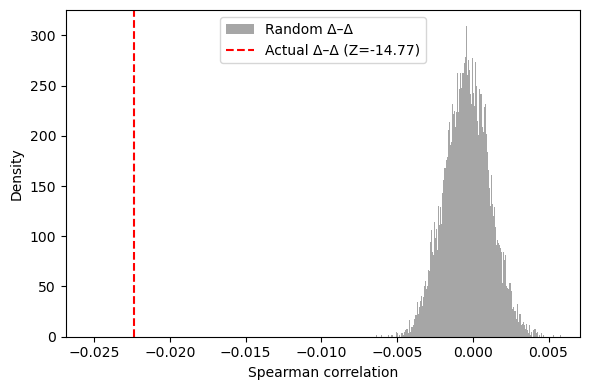

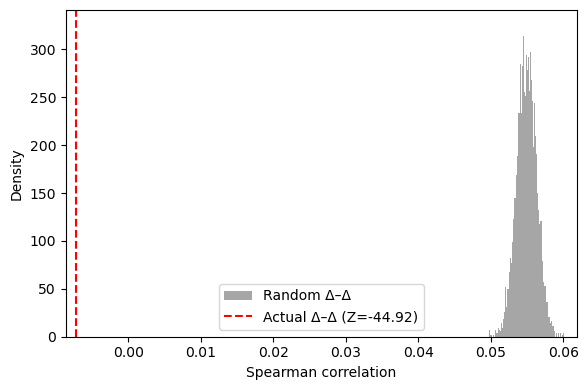

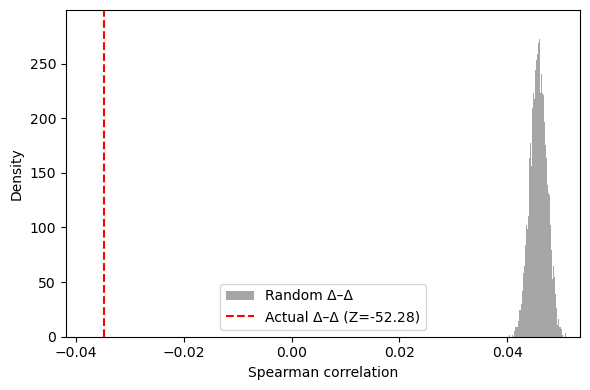


=== Cascade_gene2_regulates_gene3_regulates_gene1 ===
Gene pair  Actual Δ–Δ  Random mean  Random std    Z-score
      A–B   -0.022396    -0.000378    0.001491 -14.765471
      A–C   -0.007160     0.054944    0.001383 -44.919175
      B–C   -0.034862     0.045754    0.001542 -52.278959
[Cascade_gene2_regulates_gene3_regulates_gene1] Completed in 119.93 s


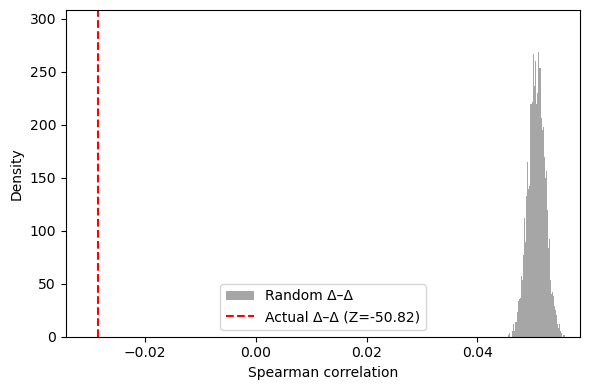

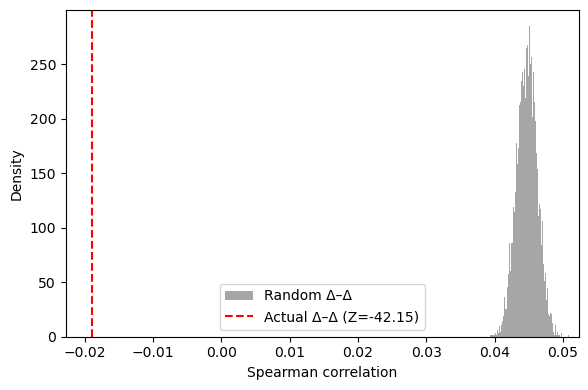

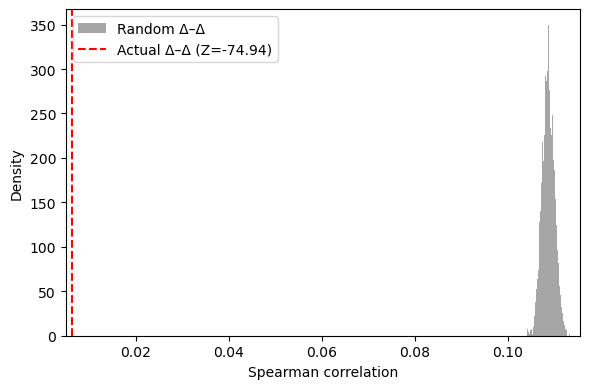


=== Fan_out_gene1_regulates_gene2&3 ===
Gene pair  Actual Δ–Δ  Random mean  Random std    Z-score
      A–B   -0.028555     0.050699    0.001559 -50.820007
      A–C   -0.018975     0.044725    0.001511 -42.147043
      B–C    0.006274     0.108691    0.001367 -74.942685
[Fan_out_gene1_regulates_gene2&3] Completed in 113.90 s


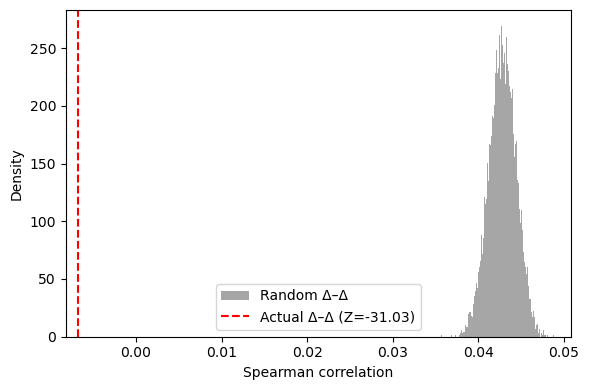

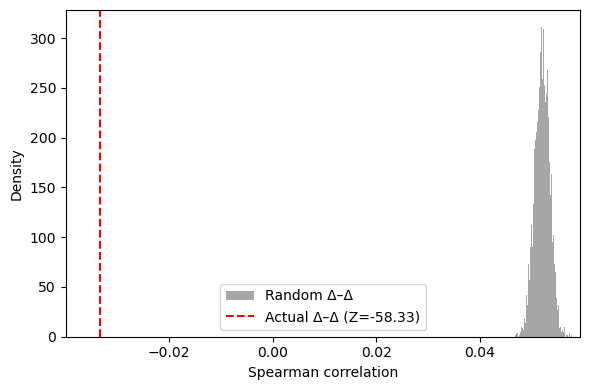

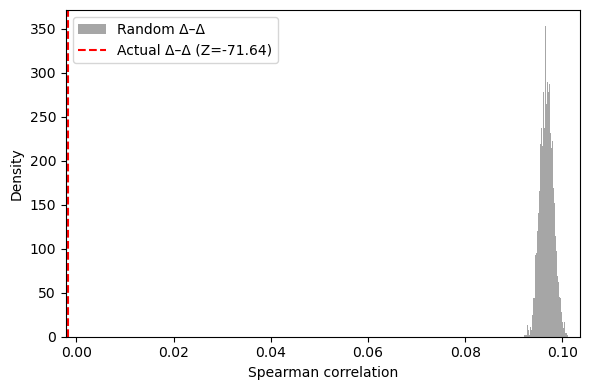


=== Asymmetric_Fan_out_gene1_regulates_gene2&3 ===
Gene pair  Actual Δ–Δ  Random mean  Random std    Z-score
      A–B   -0.006815     0.042806    0.001599 -31.026287
      A–C   -0.033301     0.052065    0.001463 -58.330813
      B–C   -0.001816     0.096746    0.001376 -71.638914
[Asymmetric_Fan_out_gene1_regulates_gene2&3] Completed in 113.04 s

=== Combined Summary ===
                                            File Gene pair  Actual Δ–Δ  \
0  Cascade_gene2_regulates_gene3_regulates_gene1       A–B   -0.022396   
1  Cascade_gene2_regulates_gene3_regulates_gene1       A–C   -0.007160   
2  Cascade_gene2_regulates_gene3_regulates_gene1       B–C   -0.034862   
3                Fan_out_gene1_regulates_gene2&3       A–B   -0.028555   
4                Fan_out_gene1_regulates_gene2&3       A–C   -0.018975   
5                Fan_out_gene1_regulates_gene2&3       B–C    0.006274   
6     Asymmetric_Fan_out_gene1_regulates_gene2&3       A–B   -0.006815   
7     Asymmetric_Fan_out_gene1_

In [7]:
# ============================================================
# Twin Δ–Δ Spearman vs Random Δ–Δ Spearman
# (Numba optimized + NaN-safe + thread-safe randomization)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from numba import njit, prange, set_num_threads, get_num_threads

# Limit threads for stability / responsiveness
set_num_threads(7)
print(f"[Numba] Using {get_num_threads()} threads.")


# -----------------------------
# Basic utilities
# -----------------------------

def extract_title(filepath: str) -> str:
    base = os.path.basename(filepath).replace(".csv", "")
    parts = base.split("_")
    if "ncells" in parts:
        idx = parts.index("ncells")
        return "_".join(parts[idx + 2 : -1]) or base
    return base


def _pearson_nan(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    ok = np.isfinite(a) & np.isfinite(b)
    a, b = a[ok], b[ok]
    if a.size < 2 or a.var(ddof=1) == 0 or b.var(ddof=1) == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


def _spearman_nan(a, b):
    a, b = np.asarray(a, float).ravel(), np.asarray(b, float).ravel()
    ok = np.isfinite(a) & np.isfinite(b)
    a, b = a[ok], b[ok]
    if a.size < 2:
        return np.nan
    ra, rb = rankdata(a), rankdata(b)
    return _pearson_nan(ra, rb)


# -----------------------------
# Twin pairing & Δ construction
# -----------------------------

def paired_twins_matrix(filepath, t1, t2,
                        time_col="time_step",
                        id_cols=("clone_id", "replicate"),
                        y_col="gene_1_mRNA",
                        x1_col="gene_2_mRNA",
                        x2_col="gene_3_mRNA"):
    df = pd.read_csv(filepath)
    keys = list(id_cols)
    cols_keep = keys + [y_col, x1_col, x2_col]

    t1_df = df.loc[df[time_col] == t1, cols_keep]
    t2_df = df.loc[df[time_col] == t2, cols_keep]

    common = t1_df[keys].drop_duplicates().merge(
        t2_df[keys].drop_duplicates(), on=keys, how="inner"
    )

    t1_df = common.merge(t1_df, on=keys).rename(
        columns={y_col: "A_t1", x1_col: "B_t1", x2_col: "C_t1"})
    t2_df = common.merge(t2_df, on=keys).rename(
        columns={y_col: "A_t2", x1_col: "B_t2", x2_col: "C_t2"})

    return t1_df.merge(t2_df, on=keys)


def build_deltas_from_matrix(M: pd.DataFrame):
    dA = (M["A_t2"] - M["A_t1"]).to_numpy()
    dB = (M["B_t2"] - M["B_t1"]).to_numpy()
    dC = (M["C_t2"] - M["C_t1"]).to_numpy()
    return dA, dB, dC


# -----------------------------
# Numba-accelerated random correlations (safe)
# -----------------------------

@njit(parallel=True, fastmath=True)
def _rank_columns(X):
    """Rank each column of X (Numba-compatible)."""
    n, m = X.shape
    R = np.empty_like(X)
    for j in prange(m):
        idx = np.argsort(X[:, j])
        ranks = np.empty(n)
        ranks[idx] = np.arange(1, n + 1)
        R[:, j] = ranks
    return R


@njit(fastmath=True)
def _corrcoef_3x3_nan_safe(X):
    """Compute correlation matrix for 3 columns (A,B,C), skip div-by-zero."""
    n = X.shape[0]
    means = np.empty(3)
    stds = np.empty(3)
    for j in range(3):
        col = X[:, j]
        means[j] = np.mean(col)
        stds[j] = np.std(col)
    corr = np.empty((3, 3))
    for i in range(3):
        for j in range(3):
            if i == j:
                corr[i, j] = 1.0
            else:
                if stds[i] == 0.0 or stds[j] == 0.0:
                    corr[i, j] = np.nan
                else:
                    num = np.sum((X[:, i] - means[i]) * (X[:, j] - means[j]))
                    corr[i, j] = num / ((n - 1) * stds[i] * stds[j])
    return corr


@njit(parallel=True, fastmath=True)
def _compute_random_corrs_inline(expr1, expr2, n_shuffles, seed=42):
    """Compute Δ–Δ correlations for many random shuffles (thread-safe)."""
    np.random.seed(seed)
    n_cells = expr1.shape[0]
    rand_corrs = np.zeros((n_shuffles, 3))
    for s in prange(n_shuffles):
        # independent permutation each iteration
        idx = np.arange(n_cells)
        np.random.shuffle(idx)
        deltas = expr1 - expr2[idx]
        ranked = _rank_columns(deltas)
        corr = _corrcoef_3x3_nan_safe(ranked)
        rand_corrs[s, 0] = corr[0, 1]
        rand_corrs[s, 1] = corr[0, 2]
        rand_corrs[s, 2] = corr[1, 2]
    return rand_corrs


def generate_random_deltas_numba(sim_df, gene_list, n_shuffles=10000, random_state=42):
    """Super-fast Numba-compiled random Δ–Δ Spearman correlations."""
    rep1 = sim_df[sim_df["replicate"] == 1].reset_index(drop=True)
    rep2 = sim_df[sim_df["replicate"] == 2].reset_index(drop=True)
    gene_cols = [f"{g}_mRNA" for g in gene_list]

    n_cells = min(len(rep1), len(rep2))
    expr1 = rep1[gene_cols].iloc[:n_cells].to_numpy(dtype=np.float64)
    expr2 = rep2[gene_cols].iloc[:n_cells].to_numpy(dtype=np.float64)

    rand_corrs = _compute_random_corrs_inline(expr1, expr2, n_shuffles, seed=random_state)
    triu = np.triu_indices(3, 1)
    return rand_corrs, triu


# -----------------------------
# Main Δ–Δ analysis (with Z-scores)
# -----------------------------

def analyze_delta_delta_correlations(filepath, t1, t2, n_shuffles=10000):
    import time
    start = time.time()

    title = extract_title(filepath)
    sim_df = pd.read_csv(filepath)

    # --- Twin Δ–Δ correlations ---
    M = paired_twins_matrix(filepath, t1, t2)
    dA, dB, dC = build_deltas_from_matrix(M)
    actual_corrs = np.array([
        _spearman_nan(dA, dB),
        _spearman_nan(dA, dC),
        _spearman_nan(dB, dC)
    ])
    pairs = ["A–B", "A–C", "B–C"]

    # --- Random Δ–Δ correlations ---
    gene_list = ["gene_1", "gene_2", "gene_3"]
    rand_corrs, triu = generate_random_deltas_numba(sim_df, gene_list, n_shuffles=n_shuffles)

    # Clean up NaNs
    valid = np.isfinite(rand_corrs).all(axis=1)
    rand_corrs_valid = rand_corrs[valid]
    if rand_corrs_valid.size == 0:
        print(f"⚠️  No valid random correlations for {title}")
        return

    rand_means = np.nanmean(rand_corrs_valid, axis=0)
    rand_stds = np.nanstd(rand_corrs_valid, axis=0, ddof=1)
    z_scores = (actual_corrs - rand_means) / rand_stds

    # --- Plot ---
    for i, pair in enumerate(pairs):
        vals = rand_corrs_valid[:, i]
        mu, sigma = rand_means[i], rand_stds[i]

        plt.figure(figsize=(6, 4))
        plt.hist(vals, bins=200, density=True, color="gray", alpha=0.7, label="Random Δ–Δ")
        # --- Dynamic window that always includes actual correlation ---
        if np.isfinite(sigma) and sigma > 1e-6:
            left, right = mu - 5 * sigma, mu + 5 * sigma
        else:
            pad = max(1e-3, 0.1 * (np.nanmax(vals) - np.nanmin(vals)))
            left, right = np.nanmin(vals) - pad, np.nanmax(vals) + pad

        # Expand if actual_corr outside range
        actual = actual_corrs[i]
        if actual < left:
            left = actual - 0.2 * abs(actual)
        if actual > right:
            right = actual + 0.2 * abs(actual)

        plt.xlim(left, right)



        plt.axvline(actual_corrs[i], color="r", linestyle="--",
                    label=f"Actual Δ–Δ (Z={z_scores[i]:.2f})")
        plt.xlabel("Spearman correlation")
        plt.ylabel("Density")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # --- Summary ---
    summary = pd.DataFrame({
        "Gene pair": pairs,
        "Actual Δ–Δ": actual_corrs,
        "Random mean": rand_means,
        "Random std": rand_stds,
        "Z-score": z_scores
    })
    print(f"\n=== {title} ===")
    print(summary.to_string(index=False))
    print(f"[{title}] Completed in {time.time() - start:.2f} s")
    return summary


# -----------------------------
# Batch runner
# -----------------------------

def run_all(files, t1, t2, n_shuffles=10000):
    all_results = []
    for fp in files:
        try:
            df = analyze_delta_delta_correlations(fp, t1, t2, n_shuffles)
            if df is not None:
                df["File"] = extract_title(fp)
                all_results.append(df)
        except Exception as e:
            print(f"❌ {extract_title(fp)} failed: {e}")
    if not all_results:
        return pd.DataFrame()
    combined = pd.concat(all_results, ignore_index=True)
    print("\n=== Combined Summary ===")
    print(combined[["File", "Gene pair", "Actual Δ–Δ", "Z-score"]])
    return combined


# -----------------------------
# Usage
# -----------------------------

if __name__ == "__main__":
    t1, t2 = 1, 10
    filepaths = [
        "/home/gzu5140/TwINFER-main 3/Simulation data/df_rows_0_1_2_23082025_000003_ncells_6000_Cascade_gene2_regulates_gene3_regulates_gene1_bbea201a.csv",
        "/home/gzu5140/TwINFER-main 3/Simulation data/df_rows_0_1_2_17092025_171204_ncells_6000_Fan_out_gene1_regulates_gene2&3_bf55ee47.csv",
        "/home/gzu5140/TwINFER-main 3/Simulation data/df_rows_0_1_2_18092025_124517_ncells_6000_Asymmetric_Fan_out_gene1_regulates_gene2&3_09decf06.csv",
    ]

    summary = run_all(filepaths, t1, t2, n_shuffles=10000)
